In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ΔΗΜΙΟΥΡΓΙΑ DATASET
np.random.seed(42)
n = 300

months_list = ["Ιαν", "Φεβ", "Μαρ", "Απρ", "Μάι", "Ιούν", "Ιούλ", "Αύγ", "Σεπ", "Οκτ", "Νοέ", "Δεκ"]

df_dashboard = pd.DataFrame({
    "Μήνας": np.random.choice(months_list, size=n),
    "Κατηγορία": np.random.choice(["Τεχνολογία", "Μόδα", "Σπίτι"], size=n, p=[0.5, 0.3, 0.2]),
    "Έσοδα": np.random.normal(loc=450, scale=120, size=n).round(2)
})

# Προσθήκη μερικών outliers
df_dashboard.loc[12, "Έσοδα"] = 1100.00
df_dashboard.loc[85, "Έσοδα"] = 1050.00

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟ LINE PLOT
# Ταξινομούμε τους μήνες σωστά ημερολογιακά
df_dashboard['Μήνας'] = pd.Categorical(df_dashboard['Μήνας'], categories=months_list, ordered=True)


In [3]:
df_dashboard

,Μήνας,Κατηγορία,Έσοδα
0,Ιούλ,Μόδα,359.17
1,Απρ,Σπίτι,344.99
2,Νοέ,Σπίτι,290.93
3,Αύγ,Τεχνολογία,357.46
4,Μάι,Σπίτι,390.61
...,...,...,...
295,Νοέ,Τεχνολογία,21.82
296,Ιούλ,Τεχνολογία,407.22
297,Σεπ,Τεχνολογία,478.60
298,Σεπ,Μόδα,381.87


In [4]:
monthly_revenue = df_dashboard.groupby('Μήνας', observed=False)['Έσοδα'].sum().reset_index()

In [5]:
monthly_revenue 

,Μήνας,Έσοδα
0,Ιαν,14092.47
1,Φεβ,10153.87
2,Μαρ,11930.12
3,Απρ,10405.08
4,Μάι,10606.58
5,Ιούν,7827.04
6,Ιούλ,13983.12
7,Αύγ,11459.43
8,Σεπ,11981.12
9,Οκτ,9874.36


Text(0.5, 0.98, 'Visual Analytics Dashboard - Πωλήσεις 2026')

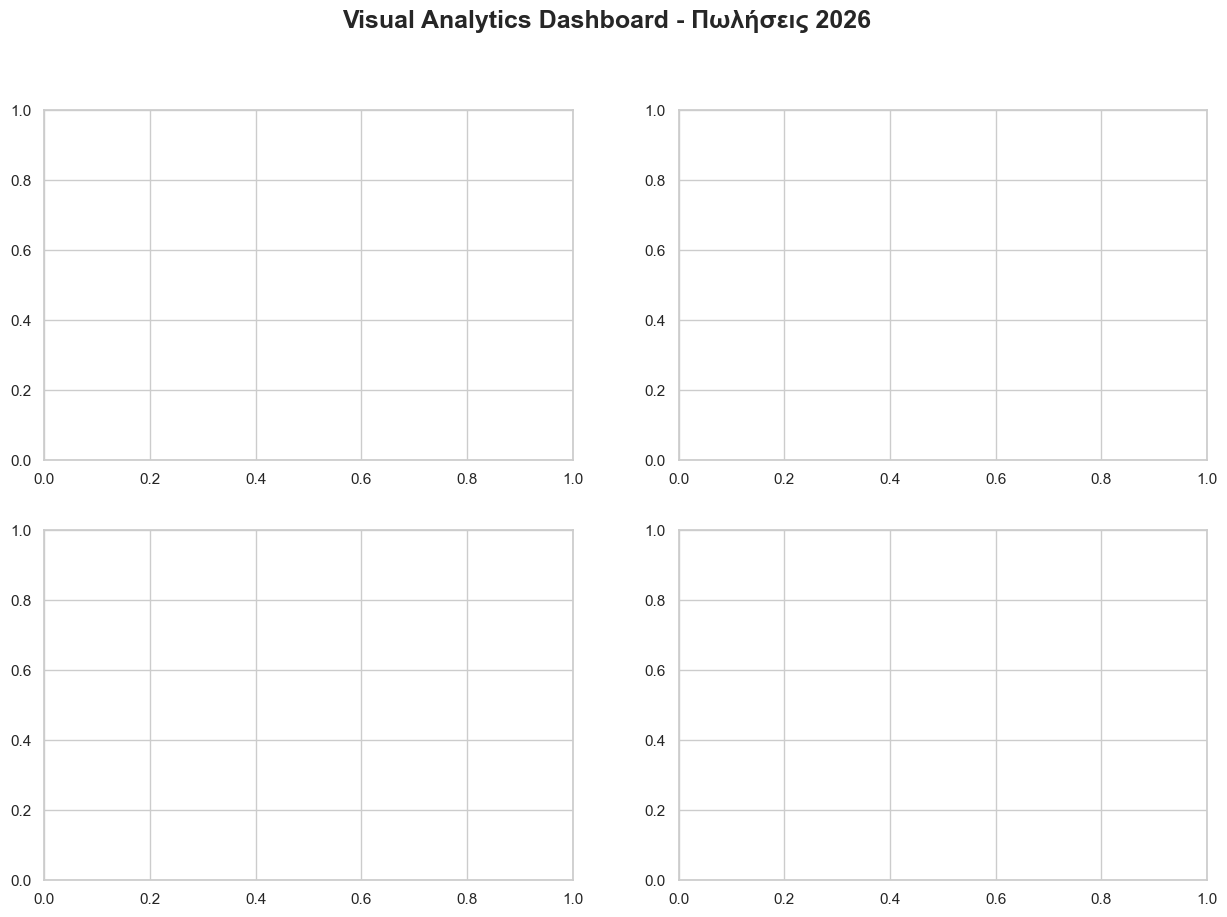

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # 2 σειρές, 2 στήλες διαγραμμάτων
fig.suptitle("Visual Analytics Dashboard - Πωλήσεις 2026", fontsize=18, fontweight='bold', y=0.98)

In [7]:
# --- ΔΙΑΓΡΑΜΜΑ 1: Line Plot (Πάνω Αριστερά) ---
sns.lineplot(ax=axes[0, 0], data=monthly_revenue, x="Μήνας", y="Έσοδα", marker="o", color="navy", linewidth=2.5)
axes[0, 0].set_title("Μηνιαία Τάση Εσόδων", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Συνολικά Έσοδα (€)")

Text(4.444444444444459, 0.5, 'Συνολικά Έσοδα (€)')

In [8]:
# --- ΔΙΑΓΡΑΜΜΑ 2: Bar Plot (Πάνω Δεξιά) ---
sns.barplot(ax=axes[0, 1], data=df_dashboard, x="Κατηγορία", y="Έσοδα", estimator=sum, palette="Blues_d", hue="Κατηγορία", legend=False)
axes[0, 1].set_title("Συνολικά Έσοδα ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 3: Box Plot (Κάτω Αριστερά) ---
sns.boxplot(ax=axes[1, 0], data=df_dashboard, x="Κατηγορία", y="Έσοδα", palette="Set2", hue="Κατηγορία", legend=False)
axes[1, 0].set_title("Κατανομή Εσόδων & Outliers ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 4: Histogram (Κάτω Δεξιά) ---
sns.histplot(ax=axes[1, 1], data=df_dashboard, x="Έσοδα", bins=20, kde=True, color="teal")
axes[1, 1].set_title("Κατανομή Συχνότητας Τιμών Παραγγελίας", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Έσοδα (€)")
axes[1, 1].set_ylabel("Πλήθος Παραγγελιών")

# Βελτιστοποίηση αποστάσεων μεταξύ των διαγραμμάτων
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 4. ΑΠΟΘΗΚΕΥΣΗ ΤΟΥ DASHBOARD
plt.savefig("sales_dashboard_2026.png", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>

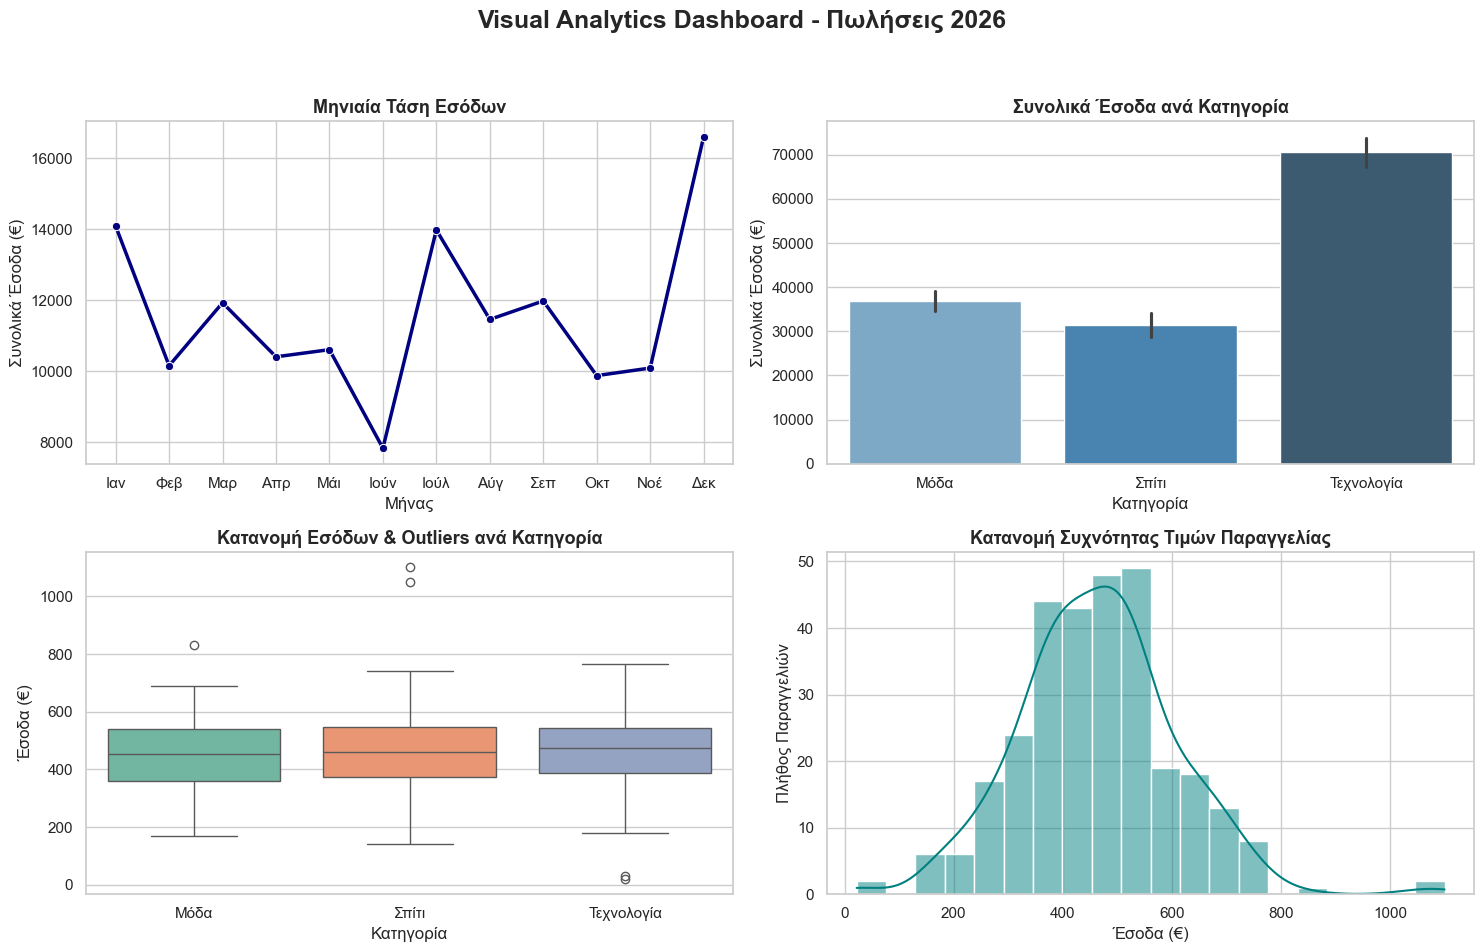

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ΔΗΜΙΟΥΡΓΙΑ DATASET
np.random.seed(42)
n = 300

months_list = ["Ιαν", "Φεβ", "Μαρ", "Απρ", "Μάι", "Ιούν", "Ιούλ", "Αύγ", "Σεπ", "Οκτ", "Νοέ", "Δεκ"]

df_dashboard = pd.DataFrame({
    "Μήνας": np.random.choice(months_list, size=n),
    "Κατηγορία": np.random.choice(["Τεχνολογία", "Μόδα", "Σπίτι"], size=n, p=[0.5, 0.3, 0.2]),
    "Έσοδα": np.random.normal(loc=450, scale=120, size=n).round(2)
})

# Προσθήκη μερικών outliers
df_dashboard.loc[12, "Έσοδα"] = 1100.00
df_dashboard.loc[85, "Έσοδα"] = 1050.00

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟ LINE PLOT
# Ταξινομούμε τους μήνες σωστά ημερολογιακά
df_dashboard['Μήνας'] = pd.Categorical(df_dashboard['Μήνας'], categories=months_list, ordered=True)
monthly_revenue = df_dashboard.groupby('Μήνας', observed=False)['Έσοδα'].sum().reset_index()

# 3. ΣΤΗΣΙΜΟ DASHBOARD (2x2 Subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # 2 σειρές, 2 στήλες διαγραμμάτων
fig.suptitle("Visual Analytics Dashboard - Πωλήσεις 2026", fontsize=18, fontweight='bold', y=0.98)

# --- ΔΙΑΓΡΑΜΜΑ 1: Line Plot (Πάνω Αριστερά) ---
sns.lineplot(ax=axes[0, 0], data=monthly_revenue, x="Μήνας", y="Έσοδα", marker="o", color="navy", linewidth=2.5)
axes[0, 0].set_title("Μηνιαία Τάση Εσόδων", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 2: Bar Plot (Πάνω Δεξιά) ---
sns.barplot(ax=axes[0, 1], data=df_dashboard, x="Κατηγορία", y="Έσοδα", estimator=sum, palette="Blues_d", hue="Κατηγορία", legend=False)
axes[0, 1].set_title("Συνολικά Έσοδα ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 3: Box Plot (Κάτω Αριστερά) ---
sns.boxplot(ax=axes[1, 0], data=df_dashboard, x="Κατηγορία", y="Έσοδα", palette="Set2", hue="Κατηγορία", legend=False)
axes[1, 0].set_title("Κατανομή Εσόδων & Outliers ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 4: Histogram (Κάτω Δεξιά) ---
sns.histplot(ax=axes[1, 1], data=df_dashboard, x="Έσοδα", bins=20, kde=True, color="teal")
axes[1, 1].set_title("Κατανομή Συχνότητας Τιμών Παραγγελίας", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Έσοδα (€)")
axes[1, 1].set_ylabel("Πλήθος Παραγγελιών")

# Βελτιστοποίηση αποστάσεων μεταξύ των διαγραμμάτων
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 4. ΑΠΟΘΗΚΕΥΣΗ ΤΟΥ DASHBOARD
plt.savefig("sales_dashboard_2026.png", dpi=300)

plt.show()

In [ ]:
#EDA#

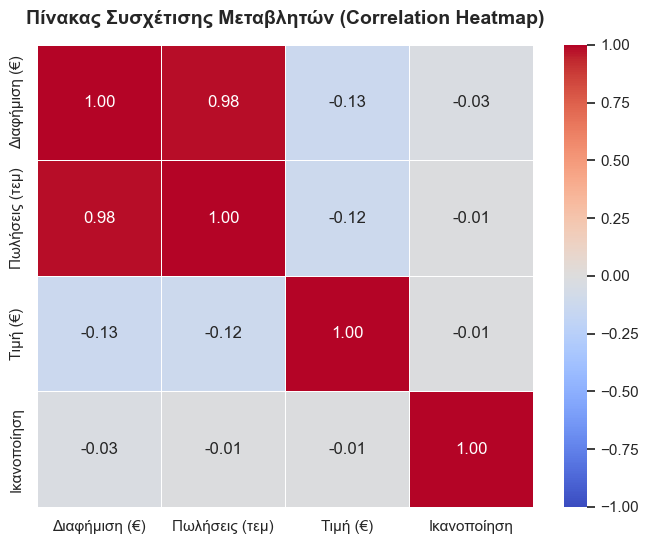

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Δημιουργούμε ένα dataset με 4 αριθμητικές μεταβλητές
np.random.seed(42)
n = 200

advertising_budget = np.random.uniform(10, 100, size=n)
# Οι πωλήσεις επηρεάζονται θετικά από τη διαφήμιση
sales = advertising_budget * 2.5 + np.random.normal(0, 15, size=n)
# Η τιμή επηρεάζει ελαφρώς αρνητικά τις πωλήσεις
price = np.random.uniform(20, 80, size=n)
# Το σκορ ικανοποίησης πελάτη
satisfaction = np.random.uniform(1, 5, size=n)

df_eda = pd.DataFrame({
    "Διαφήμιση (€)": advertising_budget,
    "Πωλήσεις (τεμ)": sales,
    "Τιμή (€)": price,
    "Ικανοποίηση": satisfaction
})

# 2. Υπολογισμός του Πίνακα Συσχέτισης (Correlation Matrix)
corr_matrix = df_eda.corr()

# 3. Σχεδιασμός του Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,         # Εμφανίζει τα νούμερα μέσα στα κουτάκια
    cmap="coolwarm",    # Μπλε = Αρνητική, Κόκκινο = Θετική συσχέτιση
    fmt=".2f",          # Στρογγυλοποίηση σε 2 δεκαδικά
    vmin=-1, vmax=1,    # Όρια της κλίμακας
    linewidths=0.5
)

plt.title("Πίνακας Συσχέτισης Μεταβλητών (Correlation Heatmap)", fontsize=14, fontweight='bold', pad=15)
plt.show()

In [13]:
import pandas as pd
import numpy as np

# 1. Δημιουργούμε ένα DataFrame με επίτηδες "τρήπες" (NaN)
data = {
    "Ηλικία": [25, 30, np.nan, 45, 22, np.nan, 38],
    "Μισθός (€)": [1200, np.nan, 1500, 2100, 1100, 1800, np.nan],
    "Πόλη": ["Αθήνα", "Θεσσαλονίκη", "Αθήνα", np.nan, "Πάτρα", "Αθήνα", "Θεσσαλονίκη"]
}

df_missing = pd.DataFrame(data)

print("--- 1. ΑΡΧΙΚΟ DATAFRAME ΜΕ ΚΕΝΑ ---")
print(df_missing)

# 2. ΕΝΤΟΠΙΣΜΟΣ ΚΕΝΩΝ (Πόσα NaN έχει κάθε στήλη;)
print("\n--- 2. ΠΛΗΘΟΣ ΚΕΝΩΝ ΑΝΑ ΣΤΗΛΗ ---")
print(df_missing.isnull().sum())

# 3. ΔΙΟΡΘΩΣΗ (IMPUTATION)
# Α) Στην Ηλικία βάζουμε τη ΔΙΑΜΕΣΟ (Median)
age_median = df_missing["Ηλικία"].median()
df_missing["Ηλικία"] = df_missing["Ηλικία"].fillna(age_median)

# Β) Στον Μισθό βάζουμε τον ΜΕΣΟ ΟΡΟ (Mean)
salary_mean = df_missing["Μισθός (€)"].mean().round(2)
df_missing["Μισθός (€)"] = df_missing["Μισθός (€)"].fillna(salary_mean)

# Γ) Στην Πόλη (κείμενο) βάζουμε την επικρατέστερη τιμή (Mode)
top_city = df_missing["Πόλη"].mode()[0]
df_missing["Πόλη"] = df_missing["Πόλη"].fillna(top_city)

print("\n--- 3. DATAFRAME ΜΕΤΑ ΤΗ ΔΙΟΡΘΩΣΗ (CLEAN) ---")
print(df_missing)

--- 1. ΑΡΧΙΚΟ DATAFRAME ΜΕ ΚΕΝΑ ---
   Ηλικία  Μισθός (€)         Πόλη
0    25.0      1200.0        Αθήνα
1    30.0         NaN  Θεσσαλονίκη
2     NaN      1500.0        Αθήνα
3    45.0      2100.0          NaN
4    22.0      1100.0        Πάτρα
5     NaN      1800.0        Αθήνα
6    38.0         NaN  Θεσσαλονίκη

--- 2. ΠΛΗΘΟΣ ΚΕΝΩΝ ΑΝΑ ΣΤΗΛΗ ---
Ηλικία        2
Μισθός (€)    2
Πόλη          1
dtype: int64

--- 3. DATAFRAME ΜΕΤΑ ΤΗ ΔΙΟΡΘΩΣΗ (CLEAN) ---
   Ηλικία  Μισθός (€)         Πόλη
0    25.0      1200.0        Αθήνα
1    30.0      1540.0  Θεσσαλονίκη
2    30.0      1500.0        Αθήνα
3    45.0      2100.0        Αθήνα
4    22.0      1100.0        Πάτρα
5    30.0      1800.0        Αθήνα
6    38.0      1540.0  Θεσσαλονίκη


In [14]:
import pandas as pd
import numpy as np

# 1. Δημιουργούμε ένα αρχικό DataFrame πωλήσεων
data = {
    "Ημερομηνία": pd.date_range(start="2026-01-01", periods=6, freq="D"),
    "Έσοδα (€)": [1500, 2200, 800, 3100, 1900, 2500],
    "Κόστος (€)": [900, 1400, 600, 1800, 1100, 1300],
    "Ηλικία_Πελάτη": [19, 45, 62, 28, 35, 51]
}

df_fe = pd.DataFrame(data)

# --- FEATURE ENGINEERING ---

# 1. Μαθηματικός συνδυασμός: Καθαρό Κέρδος & Περιθώριο Κέρδους (%)
df_fe["Κέρδος (€)"] = df_fe["Έσοδα (€)"] - df_fe["Κόστος (€)"]
df_fe["Περιθώριο_Κέρδους_%"] = ((df_fe["Κέρδος (€)"] / df_fe["Έσοδα (€)"]) * 100).round(1)

# 2. Date Extraction: Ποια ημέρα της εβδομάδας ήταν & αν είναι Σαββατοκύριακο
df_fe["Ημέρα"] = df_fe["Ημερομηνία"].dt.day_name()
df_fe["Είναι_Σαββατοκύριακο"] = df_fe["Ημερομηνία"].dt.dayofweek >= 5  # True για Σάββατο/Κυριακή

# 3. Binning: Ομαδοποίηση ηλικιών σε κατηγορίες (pd.cut)
bins = [0, 25, 50, 100]
labels = ["Νέος (18-25)", "Ενήλικας (26-50)", "Senior (51+)"]
df_fe["Ηλικιακή_Ομάδα"] = pd.cut(df_fe["Ηλικία_Πελάτη"], bins=bins, labels=labels)

print(df_fe[["Ημερομηνία", "Έσοδα (€)", "Κέρδος (€)", "Περιθώριο_Κέρδους_%", "Ημέρα", "Ηλικιακή_Ομάδα"]])

  Ημερομηνία  Έσοδα (€)  Κέρδος (€)  Περιθώριο_Κέρδους_%     Ημέρα  \
0 2026-01-01       1500         600                 40.0  Thursday   
1 2026-01-02       2200         800                 36.4    Friday   
2 2026-01-03        800         200                 25.0  Saturday   
3 2026-01-04       3100        1300                 41.9    Sunday   
4 2026-01-05       1900         800                 42.1    Monday   
5 2026-01-06       2500        1200                 48.0   Tuesday   

     Ηλικιακή_Ομάδα  
0      Νέος (18-25)  
1  Ενήλικας (26-50)  
2      Senior (51+)  
3  Ενήλικας (26-50)  
4  Ενήλικας (26-50)  
5      Senior (51+)  


In [15]:
# Υπολογισμός Συνολικού και Μέσου Κέρδους ανά Ηλικιακή Ομάδα
profit_by_age = df_fe.groupby("Ηλικιακή_Ομάδα", observed=False)["Κέρδος (€)"].agg(
    Συνολικό_Κέρδος='sum',
    Μέσο_Κέρδος='mean',
    Πλήθος_Πελατών='count'
).reset_index()

# Ταξινομούμε για να δούμε πρώτην την ομάδα με τα μεγαλύτερα συνολικά κέρδη
profit_by_age = profit_by_age.sort_values(by="Συνολικό_Κέρδος", ascending=False)

print(profit_by_age)

     Ηλικιακή_Ομάδα  Συνολικό_Κέρδος  Μέσο_Κέρδος  Πλήθος_Πελατών
1  Ενήλικας (26-50)             2900   966.666667               3
2      Senior (51+)             1400   700.000000               2
0      Νέος (18-25)              600   600.000000               1


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ΔΗΜΙΟΥΡΓΙΑ REALISTIC DATASET (Με κενά & outliers)
np.random.seed(100)
n = 250

df_project = pd.DataFrame({
    "Ημερομηνία": pd.date_range(start="2026-01-01", periods=n, freq="D"),
    "Ηλικία": np.random.choice([21, 35, 48, 65, np.nan], size=n, p=[0.25, 0.35, 0.2, 0.1, 0.1]),
    "Έσοδα": np.random.normal(loc=250, scale=60, size=n).round(2),
    "Κόστος": np.random.normal(loc=140, scale=30, size=n).round(2),
    "Rating": np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.05, 0.1, 0.2, 0.4, 0.2, 0.05])
})



In [17]:
df_project

,Ημερομηνία,Ηλικία,Έσοδα,Κόστος,Rating
0,2026-01-01,35.0,320.23,171.19,3.0
1,2026-01-02,35.0,374.66,112.07,3.0
2,2026-01-03,35.0,222.64,101.67,3.0
3,2026-01-04,65.0,288.95,111.67,5.0
4,2026-01-05,21.0,239.51,130.44,4.0
...,...,...,...,...,...
245,2026-09-03,21.0,253.58,146.39,NaN
246,2026-09-04,48.0,193.95,111.03,5.0
247,2026-09-05,65.0,186.25,170.28,5.0
248,2026-09-06,35.0,212.23,109.63,NaN


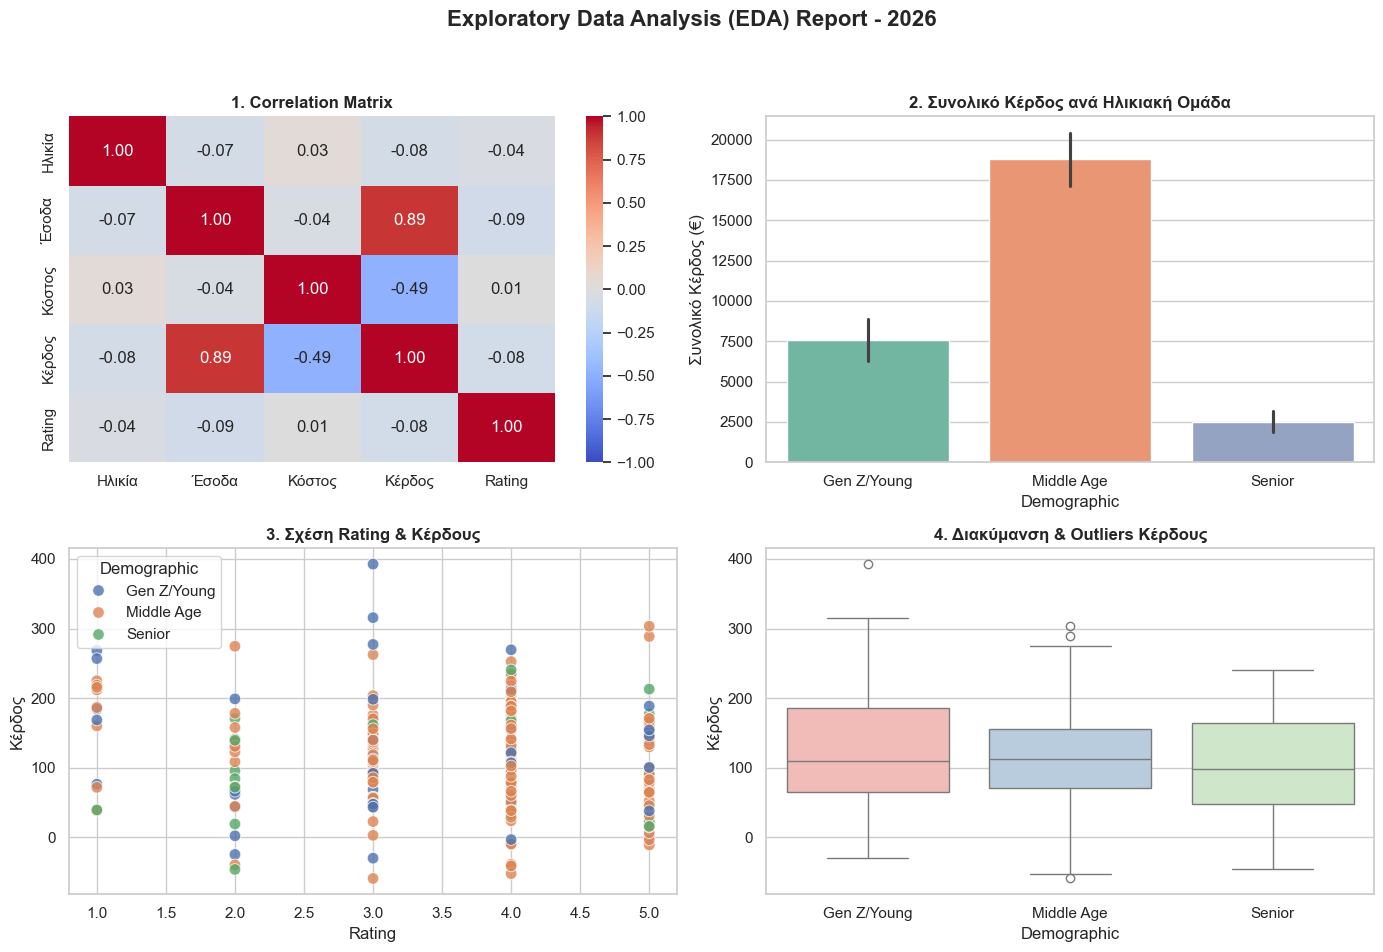

In [18]:
# Γεμίζουμε την Ηλικία με τη Διάμεσο (Median)
df_project["Ηλικία"] = df_project["Ηλικία"].fillna(df_project["Ηλικία"].median())
# Γεμίζουμε το Rating με τη Διάμεσο
df_project["Rating"] = df_project["Rating"].fillna(df_project["Rating"].median())

# --- STEP 2: FEATURE ENGINEERING ---
df_project["Κέρδος"] = df_project["Έσοδα"] - df_project["Κόστος"]
df_project["Μήνας"] = df_project["Ημερομηνία"].dt.month_name()

# Bins Ηλικίας
bins = [0, 30, 50, 100]
labels = ["Gen Z/Young", "Middle Age", "Senior"]
df_project["Demographic"] = pd.cut(df_project["Ηλικία"], bins=bins, labels=labels)

# --- STEP 3: VISUAL EDA DASHBOARD (2x2) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis (EDA) Report - 2026", fontsize=16, fontweight='bold')

# A. Correlation Heatmap (Πάνω Αριστερά)
numeric_df = df_project[["Ηλικία", "Έσοδα", "Κόστος", "Κέρδος", "Rating"]]
sns.heatmap(numeric_df.corr(), ax=axes[0, 0], annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
axes[0, 0].set_title("1. Correlation Matrix", fontweight='bold')

# B. Profit by Demographic (Πάνω Δεξιά)
sns.barplot(ax=axes[0, 1], data=df_project, x="Demographic", y="Κέρδος", estimator=sum, palette="Set2", hue="Demographic", legend=False)
axes[0, 1].set_title("2. Συνολικό Κέρδος ανά Ηλικιακή Ομάδα", fontweight='bold')
axes[0, 1].set_ylabel("Συνολικό Κέρδος (€)")

# C. Profit vs Rating Scatterplot (Κάτω Αριστερά)
sns.scatterplot(ax=axes[1, 0], data=df_project, x="Rating", y="Κέρδος", hue="Demographic", alpha=0.8, s=70)
axes[1, 0].set_title("3. Σχέση Rating & Κέρδους", fontweight='bold')

# D. Profit Distribution (Κάτω Δεξιά)
sns.boxplot(ax=axes[1, 1], data=df_project, x="Demographic", y="Κέρδος", palette="Pastel1", hue="Demographic", legend=False)
axes[1, 1].set_title("4. Διακύμανση & Outliers Κέρδους", fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Αποθήκευση
plt.savefig("eda_summary_report_2026.png", dpi=300)
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Eiagogi ton ergaleion tou Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Δημιουργουμε simulated dedomena
np.random.seed(42)
n = 200

advertising = np.random.uniform(10, 100, size=n)
cost = np.random.uniform(5, 50, size=n)
# Ta esoda exartontai amesa apo ti diafimisi kai to kostos me ligo thoryvo
revenue = (advertising * 3.5) + (cost * 1.2) + np.random.normal(0, 10, size=n)

df_ml = pd.DataFrame({
    "Diafimisi": advertising,
    "Kostos": cost,
    "Esoda": revenue
})

# VIMA 1: Xorismos se X (Features) kai y (Target)
X = df_ml[["Diafimisi", "Kostos"]]  # Ditristatos pinakas me tis anexartites metavlites
y = df_ml["Esoda"]                  # I εξαρτημενη μεταβλητη pou theloume na provlepsoume

# VIMA 2: Train / Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# VIMA 3 & 4: Dimiourgia montelou kai Ekpaideusi (.fit)
model = LinearRegression()
model.fit(X_train, y_train)

# VIMA 5: Provlepsi (.predict) sta unseen test dedomena
y_pred = model.predict(X_test)

# AXIOLOGISI (METRICS)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} €")
print(f"R² Score (Poikilomorfia pou exigoume): {r2:.4f} (δηλαδή {r2*100:.1f}%)")

Mean Absolute Error (MAE): 9.89 €
R² Score (Poikilomorfia pou exigoume): 0.9836 (δηλαδή 98.4%)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Eiagogi ton ergaleion tou Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Δημιουργουμε simulated dedomena
np.random.seed(42)
n = 200

advertising = np.random.uniform(10, 100, size=n)
cost = np.random.uniform(5, 50, size=n)
# Ta esoda exartontai amesa apo ti diafimisi kai to kostos me ligo thoryvo
revenue = (advertising * 3.5) + (cost * 1.2) + np.random.normal(0, 10, size=n)

df_ml = pd.DataFrame({
    "Diafimisi": advertising,
    "Kostos": cost,
    "Esoda": revenue
})

# VIMA 1: Xorismos se X (Features) kai y (Target)
X = df_ml[["Diafimisi", "Kostos"]]  # Ditristatos pinakas me tis anexartites metavlites
y = df_ml["Esoda"]                  # I εξαρτημενη μεταβλητη pou theloume na provlepsoume

# VIMA 2: Train / Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# VIMA 3 & 4: Dimiourgia montelou kai Ekpaideusi (.fit)
model = LinearRegression()
model.fit(X_train, y_train)

# VIMA 5: Provlepsi (.predict) sta unseen test dedomena
y_pred = model.predict(X_test)

# AXIOLOGISI (METRICS)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} €")
print(f"R² Score (Poikilomorfia pou exigoume): {r2:.4f} (δηλαδή {r2*100:.1f}%)")

Mean Absolute Error (MAE): 9.89 €
R² Score (Poikilomorfia pou exigoume): 0.9836 (δηλαδή 98.4%)


In [23]:
# 1. ΔΗΜΙΟΥΡΓΙΑ ΝΕΩΝ ΣΕΝΑΡΙΩΝ (Future Data / Unseen Scenarios)
# Φτιάχνουμε 3 νέα σενάρια διαφήμισης & κόστους για τον επόμενο μήνα
new_scenarios = pd.DataFrame({
    "Diafimisi": [120.0, 50.0, 15.0],  # Σενάριο A (Υψηλή), Β (Μεσαία), Γ (Χαμηλή)
    "Kostos": [60.0, 25.0, 10.0]
})

# 2. ΠΡΟΒΛΕΨΗ ΜΕ ΤΟ ΕΚΠΑΙΔΕΥΜΕΝΟ ΜΟΝΤΕΛΟ (.predict)
predicted_revenues = model.predict(new_scenarios)

# 3. ΠΡΟΣΘΗΚΗ ΤΩΝ ΠΡΟΒΛΕΨΕΩΝ ΣΤΟΝ ΠΙΝΑΚΑ
new_scenarios["Predicted_Revenue (€)"] = predicted_revenues.round(2)

print("--- ΠΡΟΒΛΕΨΕΙΣ ΕΣΟΔΩΝ ΓΙΑ ΝΕΑ ΣΕΝΑΡΙΑ ---")
print(new_scenarios)

--- ΠΡΟΒΛΕΨΕΙΣ ΕΣΟΔΩΝ ΓΙΑ ΝΕΑ ΣΕΝΑΡΙΑ ---
   Diafimisi  Kostos  Predicted_Revenue (€)
0      120.0    60.0                 491.47
1       50.0    25.0                 205.35
2       15.0    10.0                  65.26


In [24]:
# 1. Τα βάρη των μεταβλητών (Coefficients - β1, β2)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (Weight)": model.coef_
})

print("--- ΒΑΡΗ ΜΕΤΑΒΛΗΤΩΝ (Coefficients) ---")
print(coefficients)

# 2. Ο σταθερός όρος (Intercept - β0)
print(f"\nIntercept (β0): {model.intercept_:.2f}")

--- ΒΑΡΗ ΜΕΤΑΒΛΗΤΩΝ (Coefficients) ---
     Feature  Coefficient (Weight)
0  Diafimisi              3.492799
1     Kostos              1.189183

Intercept (β0): 0.98
